In [1]:
import cfe

cfe.logger.setLevel("DEBUG")

cfe.settings.backend = "cfe_docker"
# cfe.settings.backend = "conda"

[09/25/2025 06:19:51] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")
fadata

[09/25/2025 06:19:52] DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                                  


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

                      DEBUG    CFEDockerBackend __init__                                                                                                                                                
                      DEBUG    Docker image(huangzhaoyang/veloae:0.0.1) loaded, entry point is 'None'                                                                                                   
                      DEBUG    Loaded function 'veloae': <function veloae at 0x78f1e3823640>                                                                                                            
                      INFO     method backend loaded: CFE Docker Backend: veloae in docker image 'huangzhaoyang/veloae:0.0.1'                                                                           
                      DEBUG    merged parameters: {'repreprocess': True}                                                                                                                            

<Axes: title={'center': 'clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

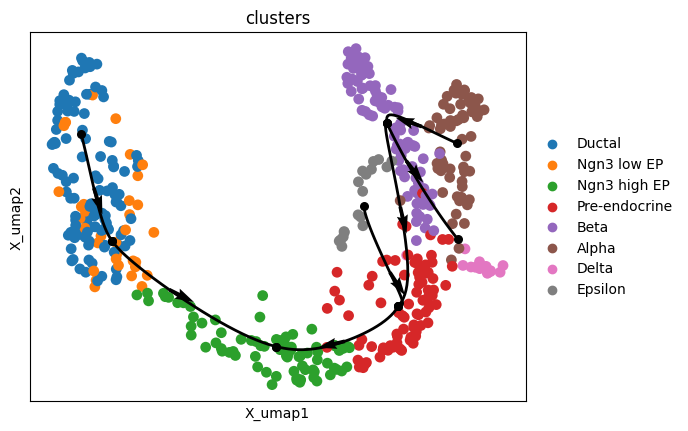

In [3]:
method = cfe.method.FateMethod(method_name="veloae")
method.infer_trajectory(fadata, parameters={"repreprocess": True})
cfe.plot.plot_trajectory(fadata, color="clusters")